In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### 01. 데이터 확인

In [7]:
df = pd.read_csv('../../Kaggle/Kaggle-Titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df_test = pd.read_csv('../../Kaggle/Kaggle-Titanic/test.csv')
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.shape

(891, 12)

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [13]:
# 컬럼별 null data % 출력
# {:>10} 오른쪽 정렬
for col in df.columns:
    msg = 'column : {:>10}\t Percent of Nan value : {:2f}%'.format(col, (df[col].isnull().sum() / df[col].shape[0])* 100)
    print(msg)

column : PassengerId	 Percent of Nan value : 0.000000%
column :   Survived	 Percent of Nan value : 0.000000%
column :     Pclass	 Percent of Nan value : 0.000000%
column :       Name	 Percent of Nan value : 0.000000%
column :        Sex	 Percent of Nan value : 0.000000%
column :        Age	 Percent of Nan value : 19.865320%
column :      SibSp	 Percent of Nan value : 0.000000%
column :      Parch	 Percent of Nan value : 0.000000%
column :     Ticket	 Percent of Nan value : 0.000000%
column :       Fare	 Percent of Nan value : 0.000000%
column :      Cabin	 Percent of Nan value : 77.104377%
column :   Embarked	 Percent of Nan value : 0.224467%


- Age, Cabin 컬럼에서 Null값이 많다.

### 02. 전체 생존확률 확인

Text(0.5, 1.0, 'Survived')

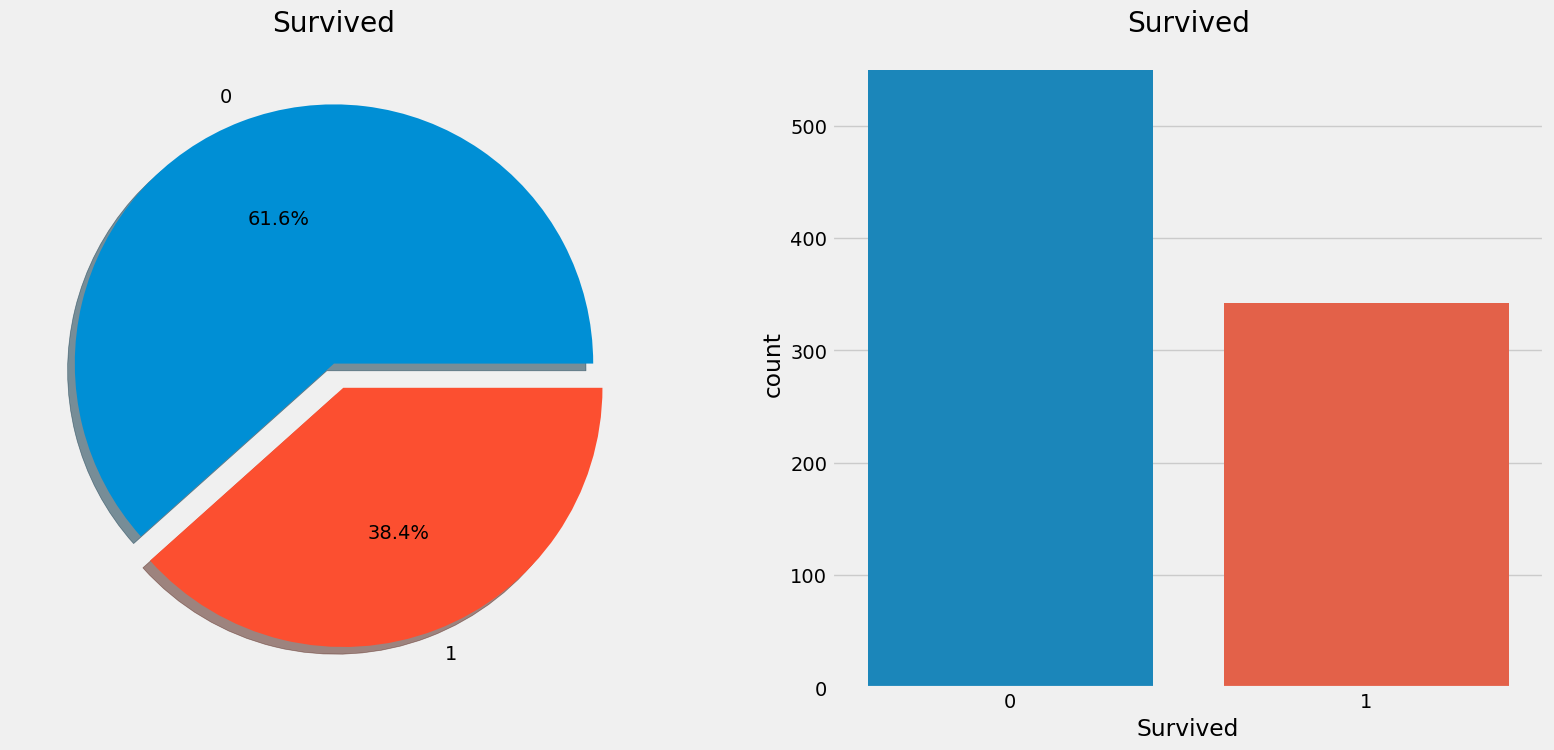

In [14]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df['Survived'].value_counts().plot.pie(explode=[0, 0.1], autopct ='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
sns.countplot(x='Survived', data=df, ax=ax[1])
ax[1].set_title('Survived')

- 생존한 사람 38.4%, 생존하지 못한 사람 61.6%로 생존하지 못한 사람의 비율이 더 높다.

In [15]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### 0.3 각 컬럼별 생존 비율 확인하기

- Type of Features
    - Categorical Features : 두 개 이상의 범주를 가지며 해당 특성의 값이 그 범주로 분류될 수 있는 변수를 의미, 순서가 정해져있지 않다.
        eg. Sex, Embarked
    - Ordinal Features : 상대적인 순서나 정렬을 가질 수 있다. eg. Pclass
    - Continuous Feature : 해당 특성의 열에서 최솟값과 최댓값 사이, 어떤 두 점 사이 값들을 가질 수 있는 경우
        eg. Age

#### 03-01. 성별에 따른 생존 비율 확인(Categorical Feature)
- Sex로 groupby된 Sex, Survived 데이터로 막대 그래프 그리기
- 성별 Survived여부에 따른 막대그래프 그리기

In [16]:
# 데이터 프레임으로 성별 생존 확률 확인하기
df[['Survived', 'Sex']].groupby(['Sex']).mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [17]:
# Cross tab으로 성별 생존여부 확인하기
pd.crosstab(df['Survived'], df['Sex']).style.background_gradient('summer_r')

Sex,female,male
Survived,,
0,81,468
1,233,109


Text(0.5, 1.0, 'Sex:Survived vs Dead')

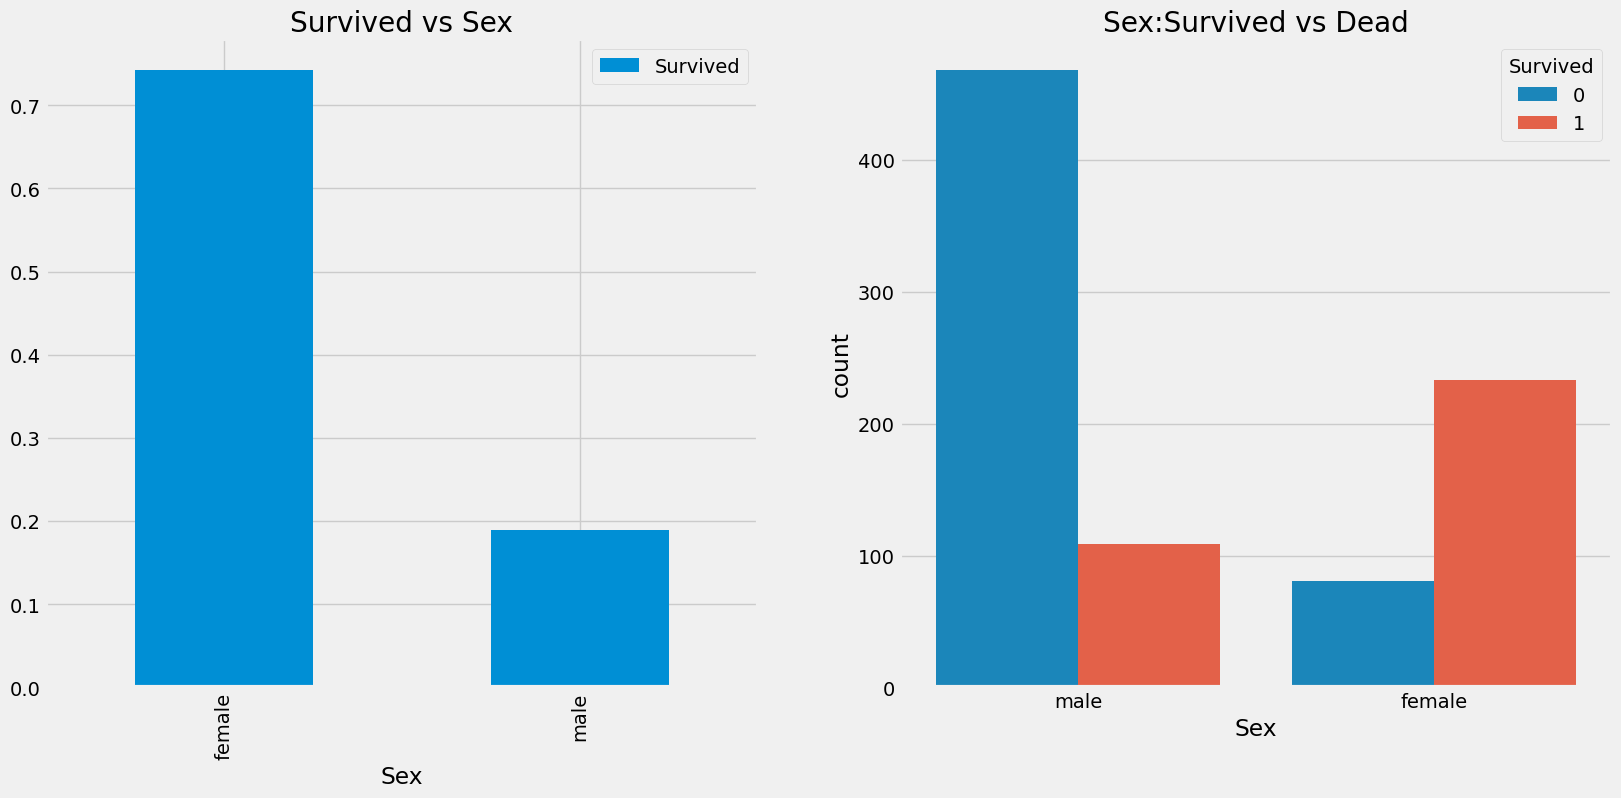

In [19]:
#막대그래프로 성별 생존여부 확인하기
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex', hue='Survived', data=df, ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')

- 여성 생존 확률이 남성 생존 확률보다 월등히 높다.

#### 03-02. Pclass에 따른 생존여부 확인하기(Ordinal Features)

In [20]:
#데이터 프레임으로 등급별 생존여부 확인
df[['Pclass','Survived']].groupby(['Pclass']).sum()

,Survived
Pclass,
1,136
2,87
3,119


In [21]:
# 데이터 프레임으로 생존 확률 확인하기
df[['Survived','Pclass']].groupby('Pclass').mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [22]:
# Crosstab으로 확인
pd.crosstab(df['Pclass'], df['Survived']).style.background_gradient('summer_r')

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Text(0.5, 1.0, 'Pclass : Survived vs Dead')

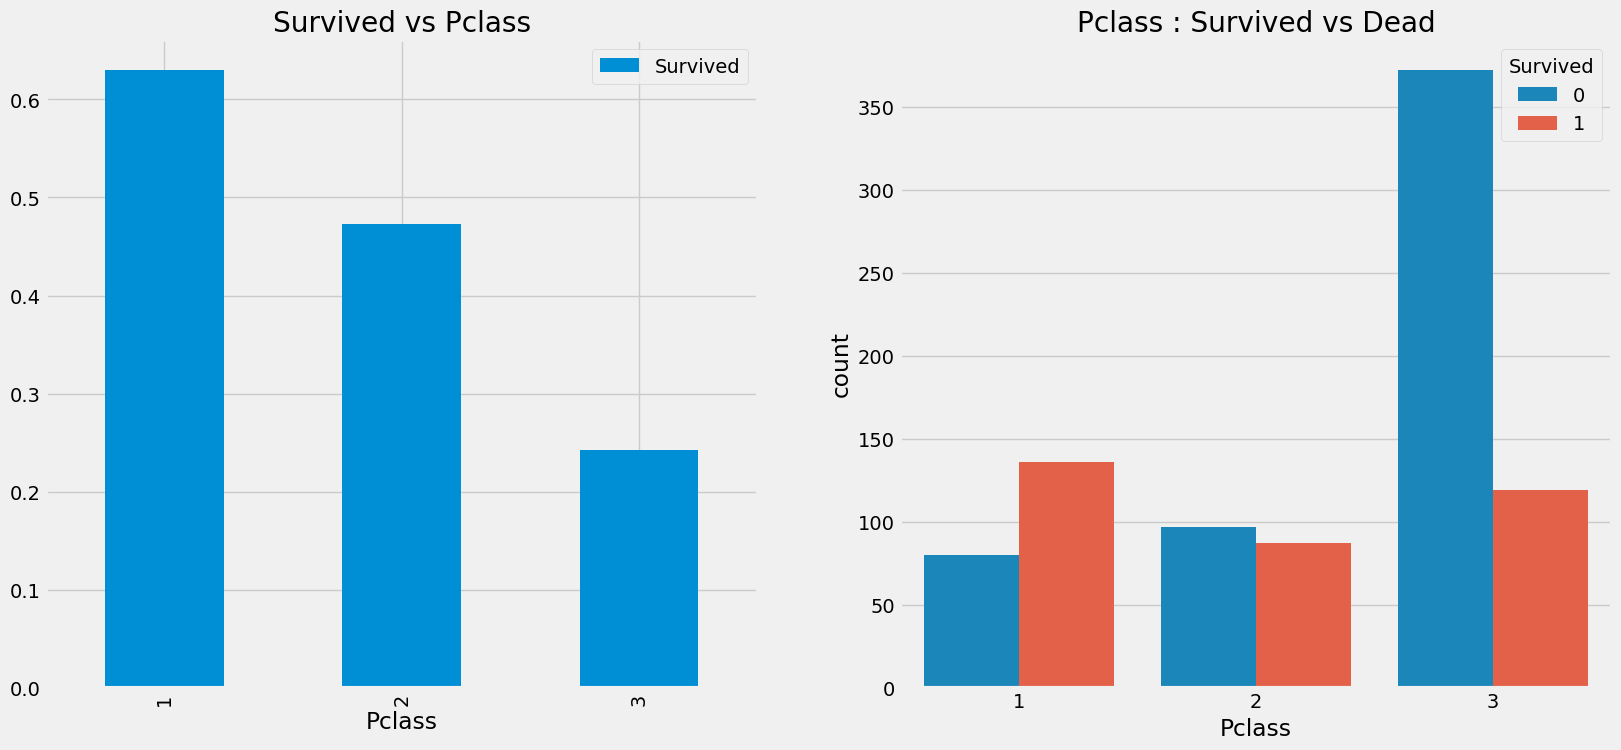

In [23]:
#막대그래프로 확인
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df[['Pclass','Survived']].groupby(['Pclass']).mean().sort_values(by='Survived', ascending=False).plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Pclass')
sns.countplot(x='Pclass', hue='Survived', data=df, ax=ax[1])
ax[1].set_title('Pclass : Survived vs Dead')

- 등급이 높을 수록 생존 확률이 높다.
- 3등급 탑승객 수가 제일 많지만 생존 확률이 가장 낮다.

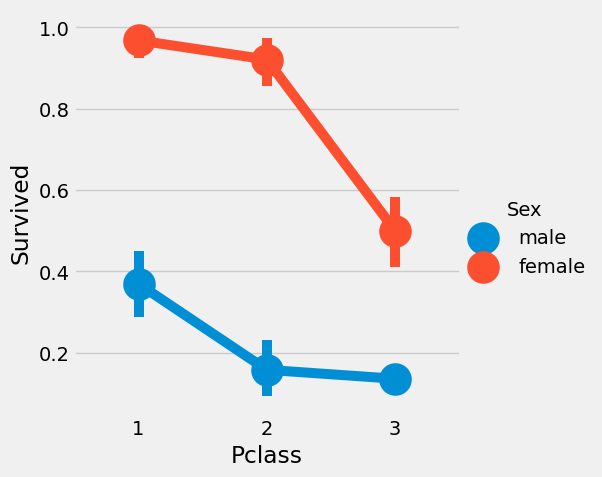

In [24]:
# catplot으로 등급별, 성별 생존 여부 확인
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=df, kind='point')

- 성별 관계없이 1등급 탑승객의 생존 여부가 높고, 남성보다 여성의 생존 확률이 높다.

#### 03-03. Age에 따른 생존여부 확인하기(Continuous Features)

In [25]:
# 최연장, 최연소 탑승객 나이, 평균 나이 확인
print('The Oldest Passenger\'s age : {} Years'.format(df['Age'].max()))
print('The Youngest Passenger\'s age : {} Years'.format(df['Age'].min()))
print('The Average Age of All Passengers is : {:.1f} Years'.format(df['Age'].mean()))

The Oldest Passenger's age : 80.0 Years
The Youngest Passenger's age : 0.42 Years
The Average Age of All Passengers is : 29.7 Years


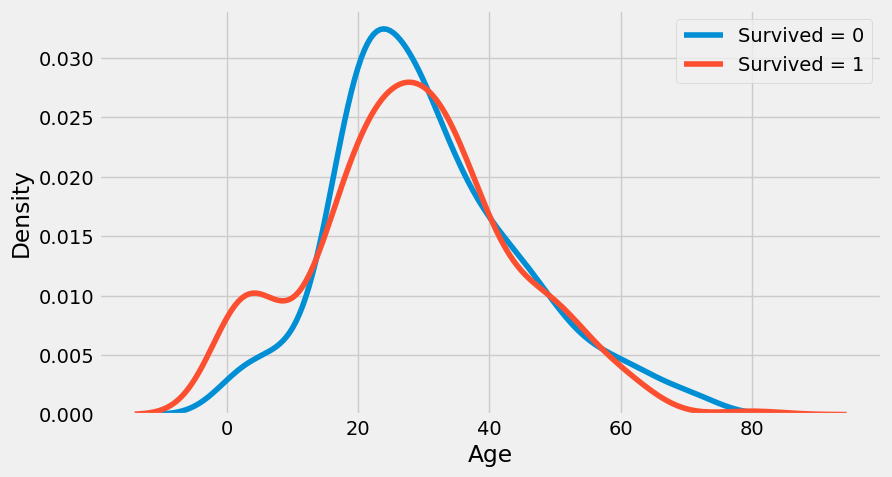

In [26]:
# kdeplot으로 나이 별 생존 여부 분포 확인
f, ax = plt.subplots(1, 1, figsize=(9, 5))
sns.kdeplot(df[df['Survived']==0]['Age'], ax=ax)
sns.kdeplot(df[df['Survived']==1]['Age'], ax=ax)
plt.legend(['Survived = 0', 'Survived = 1'])
plt.show()

- 나이가 어린 탑승객의 생존 확률이 높다.

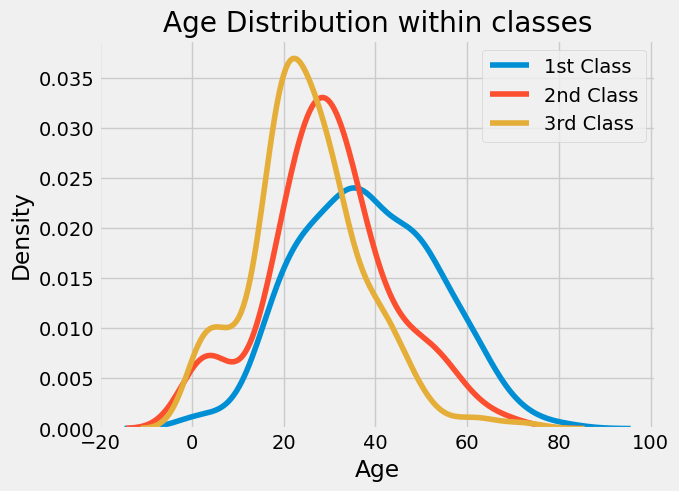

In [27]:
# Pclass 별 나이 분포 확인
sns.kdeplot(df[df['Pclass']==1]['Age'])
sns.kdeplot(df[df['Pclass']==2]['Age'])
sns.kdeplot(df[df['Pclass']==3]['Age'])
plt.title('Age Distribution within classes')
plt.legend(['1st Class', '2nd Class', '3rd Class'])

- 2등급, 3등급에 어린이의 분포가 많음.
- 1등급에 나이 많은 탑승객의 비중이 크다.

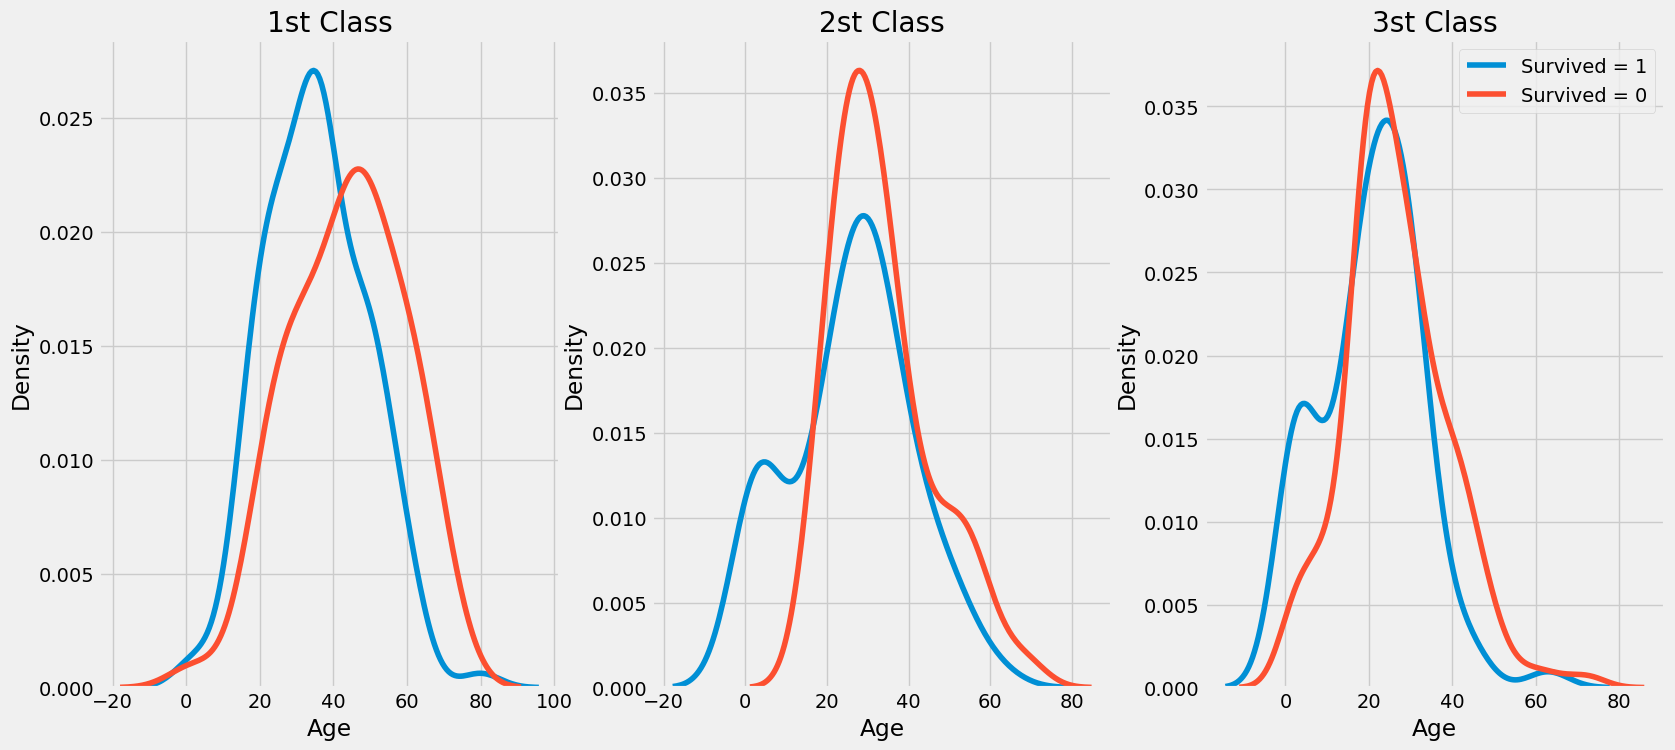

In [28]:
# 탑승 등급별, 나이별 생존 분포 확인 
f, ax = plt.subplots(1, 3, figsize=(18, 8))
sns.kdeplot(df[(df['Survived']==1) & (df['Pclass']==1)]['Age'], ax=ax[0])
sns.kdeplot(df[(df['Survived']==0) & (df['Pclass']==1)]['Age'], ax=ax[0])
ax[0].set_title('1st Class')

sns.kdeplot(df[(df['Survived']==1) & (df['Pclass']==2)]['Age'], ax=ax[1])
sns.kdeplot(df[(df['Survived']==0) & (df['Pclass']==2)]['Age'], ax=ax[1])
ax[1].set_title('2st Class')

sns.kdeplot(df[(df['Survived']==1) & (df['Pclass']==3)]['Age'], ax=ax[2])
sns.kdeplot(df[(df['Survived']==0) & (df['Pclass']==3)]['Age'], ax=ax[2])
ax[2].set_title('3st Class')
plt.legend(['Survived = 1', 'Survived = 0'])

- 등급에 상관없이 어린 아이들의 생존 확률은 높다.
- 1등급 탑승객 중 20-40대 탑승객의 생존 확률이 높다.

<Axes: xlabel='Sex', ylabel='Age'>

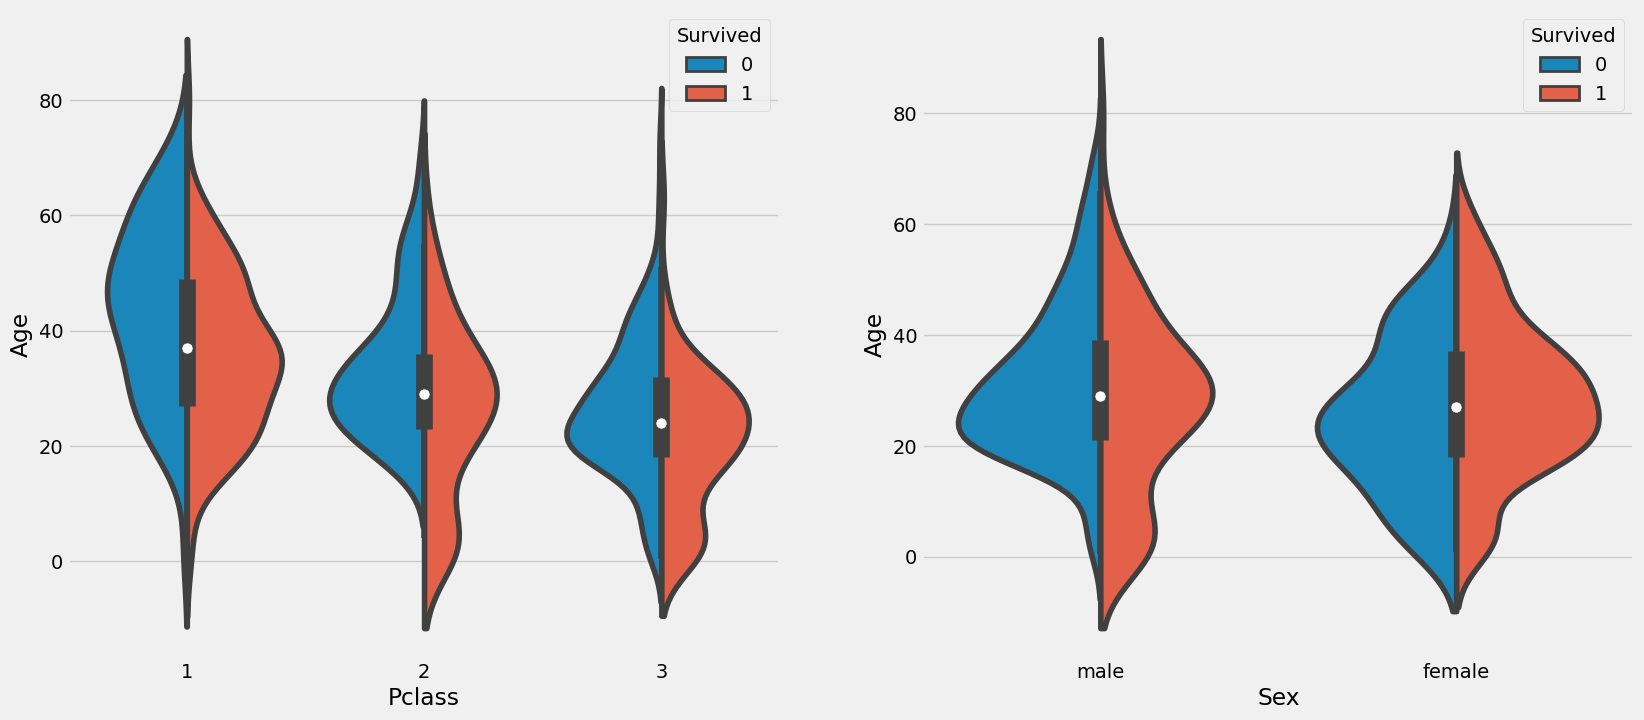

In [29]:
# 성별, 나이별 생존 확률 분포
f, ax = plt.subplots(1, 2, figsize=(18, 8))
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True, ax=ax[0])
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df, split=True, ax=ax[1])

- 아동의 수는 등급이 낮아질 수록 많다.
- 10세 이하의 탑승객의 생존비율이 높다.
- 20-50대의 1등급 탑승객의 생존비율이 높다.

#### 03-04. Embarked 에 따른 생존 확률 확인하기

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
#탑승구별 생존 여부 확인하기
df[['Embarked','Survived']].groupby('Embarked').value_counts()

Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           217
Name: count, dtype: int64

Text(0.5, 1.0, 'Embarked vs Pclass')

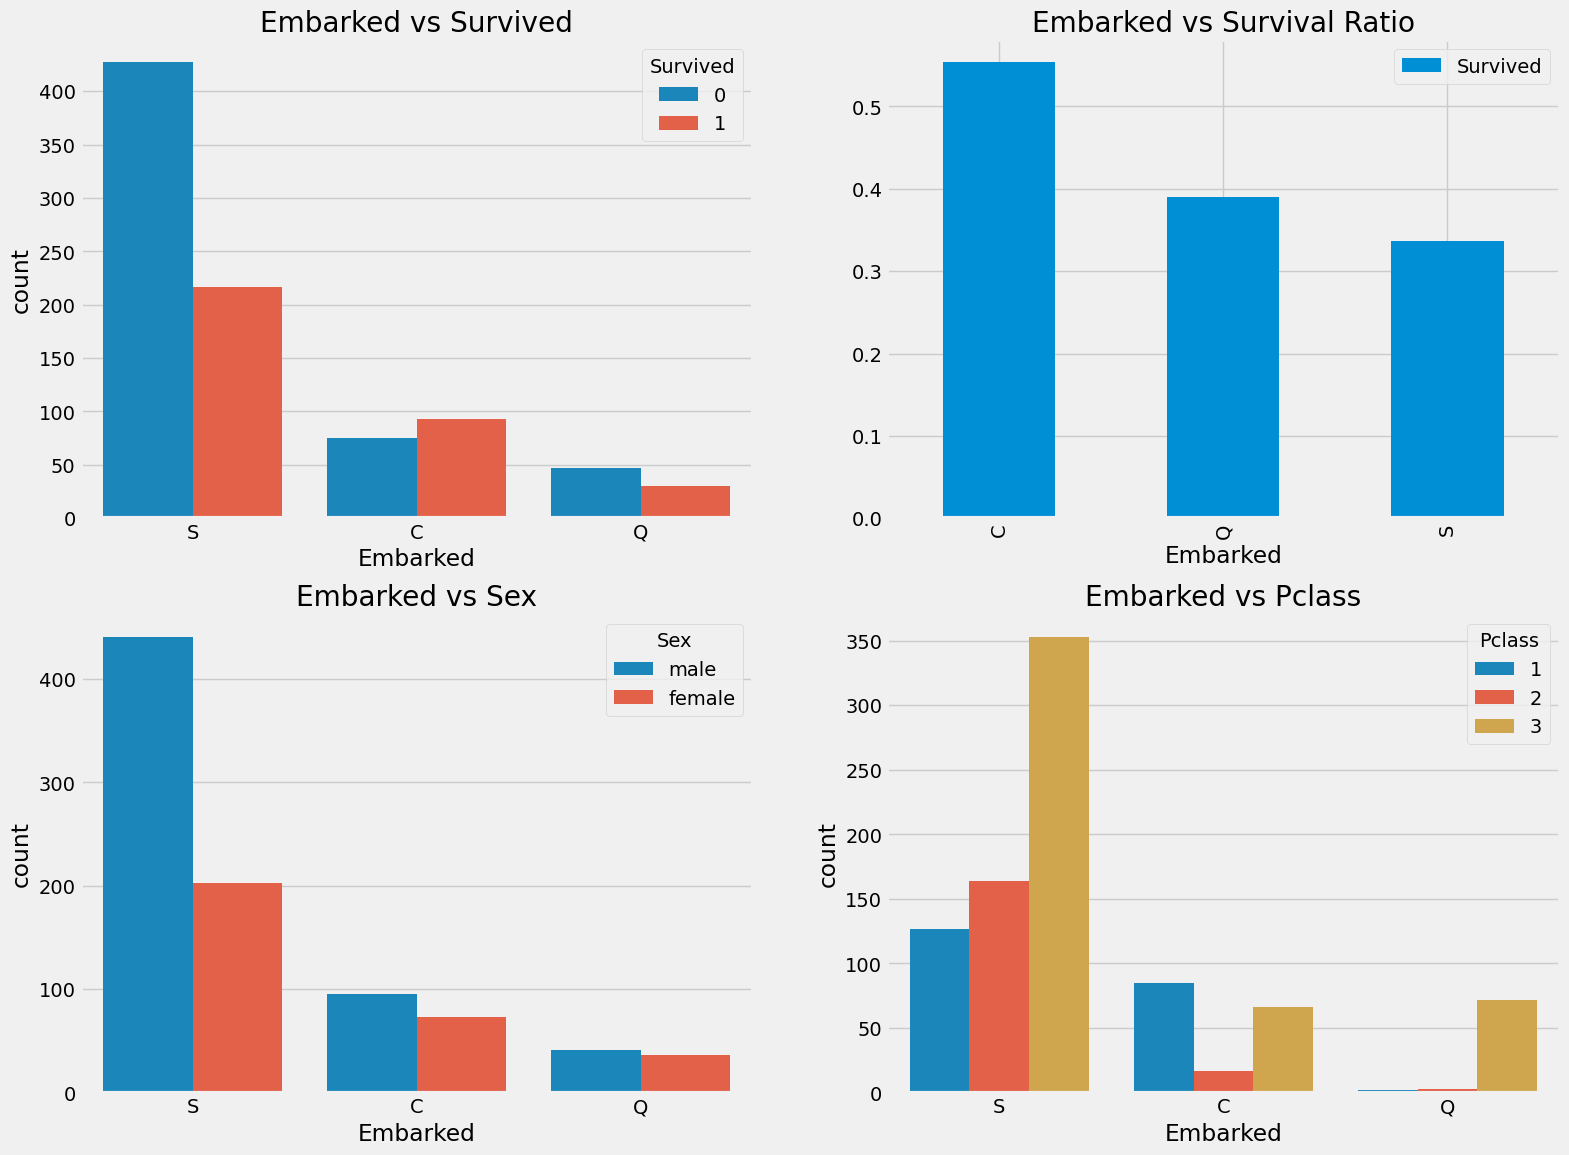

In [32]:
f, ax = plt.subplots(2, 2, figsize=(17, 13))

#countplot으로 탑승구별 생존여부 확인하기
sns.countplot(data=df, x='Embarked', hue='Survived', ax=ax[0, 0])
ax[0,0].set_title('Embarked vs Survived')

# 탑승구별 평균 생존 확률 확인
df[['Embarked', 'Survived']].groupby('Embarked').mean().plot.bar(ax=ax[0,1])
ax[0,1].set_title('Embarked vs Survival Ratio')

# 탑승구별, 성별 탑승객 확인
sns.countplot(data=df, x='Embarked', hue='Sex', ax=ax[1, 0])
ax[1,0].set_title('Embarked vs Sex')

#탑승구별, 등급별 탑승객 확인
sns.countplot(data=df, x='Embarked', hue='Pclass', ax=ax[1, 1])
ax[1, 1].set_title('Embarked vs Pclass')


- C 탑승구에서 탄 탑승객의 평균 생존확률이 높고, S등급에서 탄 탑승객의 평균 생존확률이 낮다.
- C 탑승구에서 탄 탑승객 중 1등급 탑승객의 비율이 높다.
- S 탑승구에서 탄 탑승객 중 3등급 탑승객의 비율이 높다.

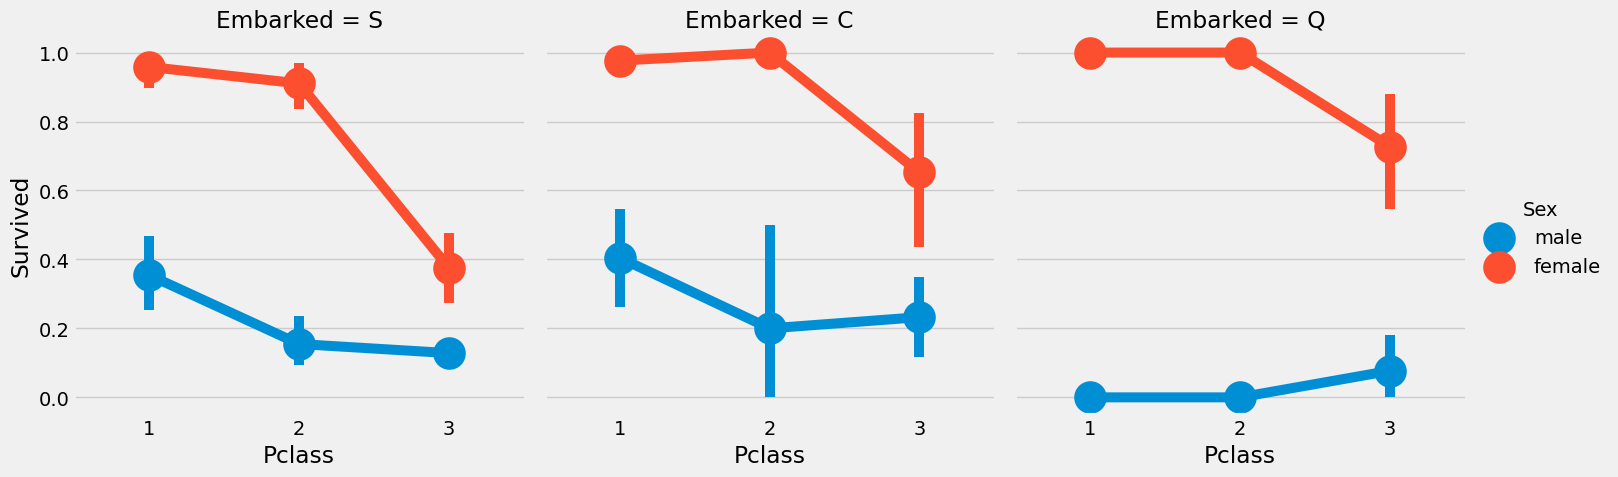

In [33]:
# catplot으로 성별, 등급별, 탑승구 별 생존 여부 확인하기
sns.catplot(data=df, x='Pclass', y='Survived', hue='Sex', col='Embarked', kind='point')

- 1등급과 2등급의 여성 탑승객의 생존확률은 1에 근접한다.
- S 항구의 3등급 탑승객은 남성과 여성 모두 생존율이 낮다.
- Q 항구의 남성 탑승객 생존율은 매우 낮고, Q항구 탑승객의 대부분은 3등급 탑승객이다.

#### 03-05. Family 수로 생존여부 확인하기

- Family = SibSp + Parch + 1(본인)
- Family로 합쳐서 분석

In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
# FamilySize 컬럼 생성
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df_test['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [36]:
# 최대, 최소 가족 규모 구하기
print('Maximum size of Family : ', df['FamilySize'].max())
print('Minimum size of Family : ', df['FamilySize'].min())

Maximum size of Family :  11
Minimum size of Family :  1


In [37]:
df['FamilySize'].head()

0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64

Text(0.5, 1.0, 'FamilySize vs Survived')

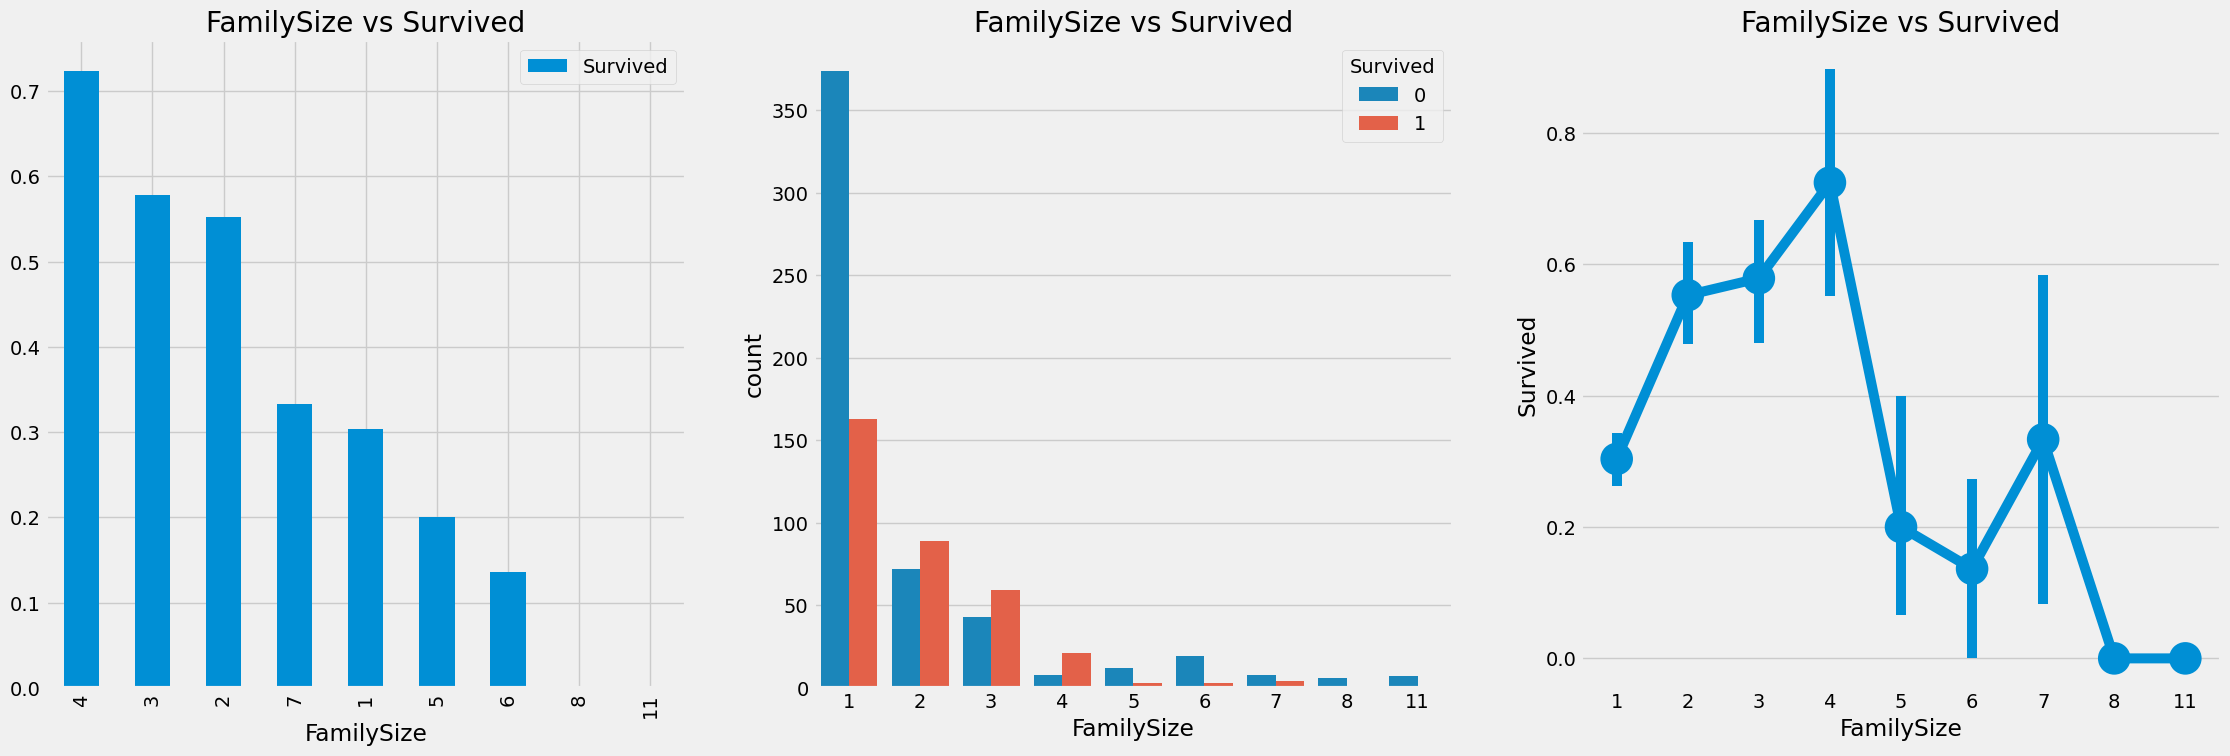

In [40]:
f, ax = plt.subplots(1, 3, figsize=(25, 8))

# 막대 그래프로 가족 규모 별 생존 확률 확인
df[['FamilySize', 'Survived']].groupby('FamilySize').mean().sort_values(by='Survived', ascending=False).plot.bar(ax=ax[0])
ax[0].set_title('FamilySize vs Survived')

# 막대 그래프로 가족 규모 별 생존 여부 확인
sns.countplot(data=df, x='FamilySize', hue='Survived', ax=ax[1])
ax[1].set_title('FamilySize vs Survived')

# pointplot으로 가족 규모 별 생존 확률 확인
sns.pointplot(data=df, x='FamilySize', y='Survived', ax=ax[2])
ax[2].set_title('FamilySize vs Survived')


- 2-3명의 가족 규모에서 가장 높은 생존 확률을 보인다.

In [39]:
# crosstab으로 가족 규모 별 탑승 등급 확인
pd.crosstab(df['FamilySize'], df['Pclass']).style.background_gradient('summer_r')

Pclass,1,2,3
FamilySize,,,
1,109,104,324
2,70,34,57
3,24,31,47
4,7,13,9
5,2,1,12
6,4,1,17
7,0,0,12
8,0,0,6
11,0,0,7


- 가족 규모가 큰 탑승객(7~11명) 은 3등급 탑승객이다.
- 혼자인 탑승객의 수가 가장 많다.
- 2명 탑승객 중 1등급 탑승객이 많고, 3명 탑승객은 3등급, 4명 탑승객은 2등급 탑승객이 가장 많다.

#### 03-06. Fare별 생존 여부 확인(Continuous Feature)
- sns.distplot : histplot과 displot으로 대체됨. histplot과 density curve 함께 분포확인 가능
- .skew() : 비대칭도. 평균에 대해 최빈값이 얼마나 치우쳐져 있는 나타내는 척도

In [45]:
# Fare 최댓값, 최솟값 확인
print('The Highest Fare was : ', df['Fare'].max())
print('The Lowest Fare was : ', df['Fare'].min())
print('The Average Fare was : ', df['Fare'].mean())

The Highest Fare was :  512.3292
The Lowest Fare was :  0.0
The Average Fare was :  32.204207968574636


<Axes: xlabel='Fare', ylabel='Density'>

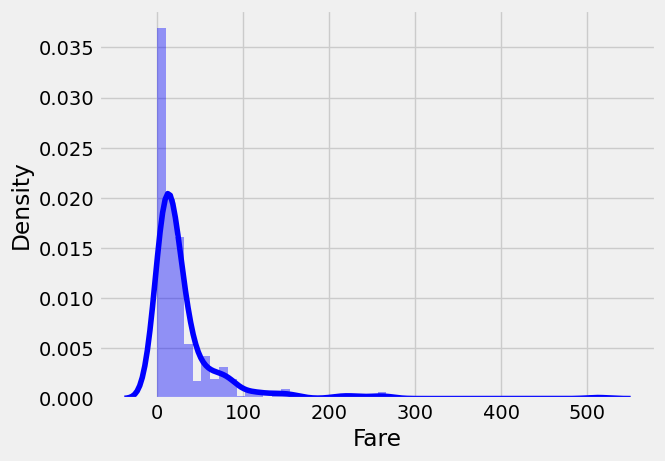

In [43]:
# distplot으로 Fare  컬럼의 skewness 확인
sns.distplot(df['Fare'], color ='b')

Text(0.5, 1.0, 'Fares in Pclass 3')

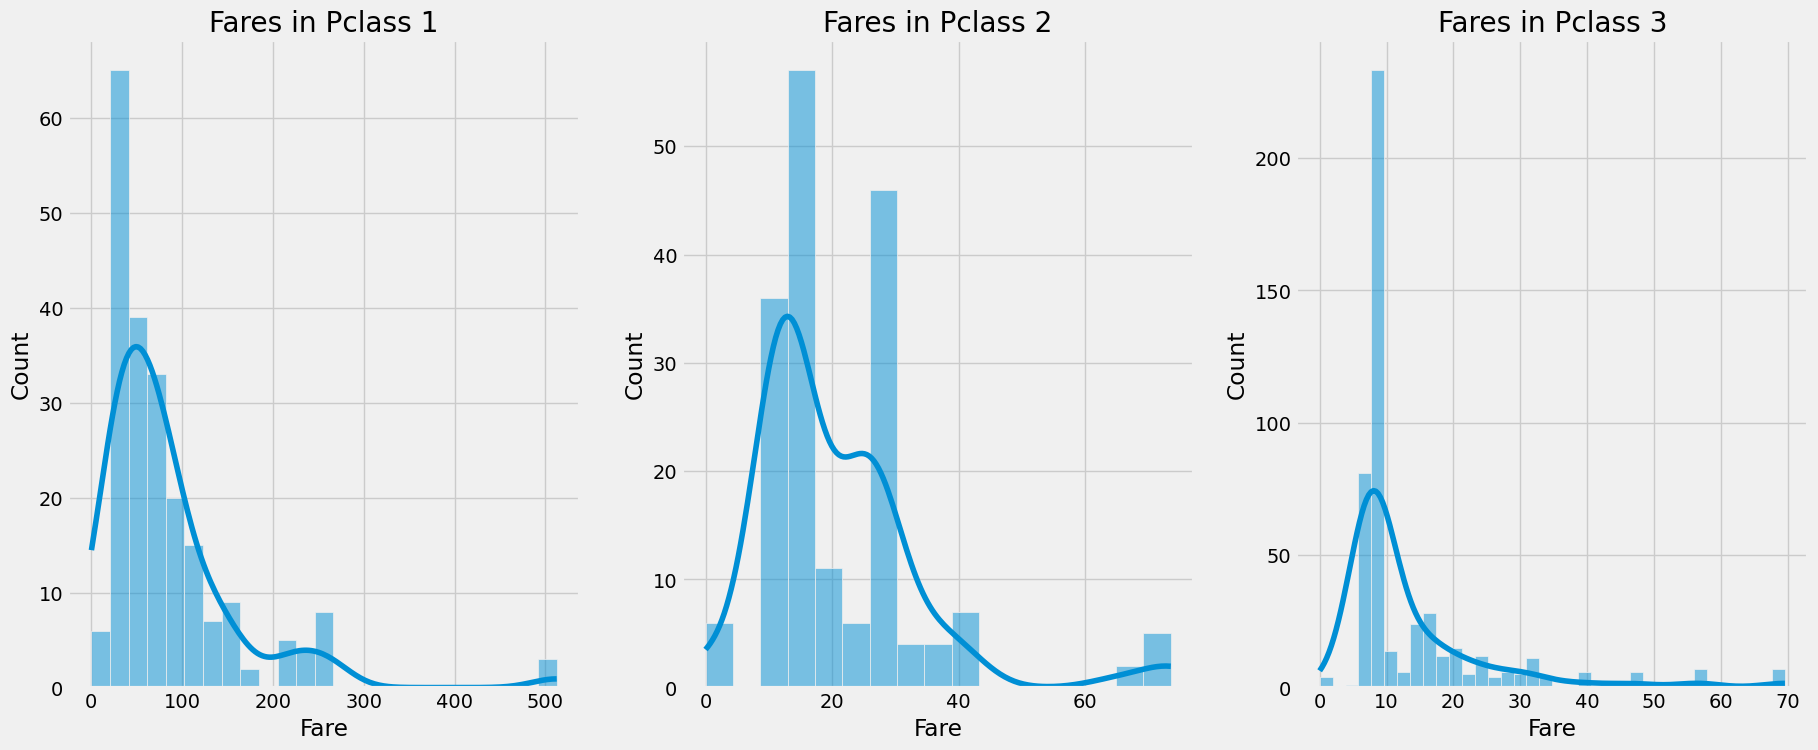

In [48]:
# 등급별 Fare 분포 확인
f, ax = plt.subplots(1, 3, figsize=(20, 8))
sns.histplot(x=df[df['Pclass']==1]['Fare'], data=df, ax=ax[0], kde=True)
ax[0].set_title('Fares in Pclass 1')

sns.histplot(x=df[df['Pclass']==2]['Fare'], data=df, ax=ax[1], kde=True)
ax[1].set_title('Fares in Pclass 2')

sns.histplot(x=df[df['Pclass']==3]['Fare'], data=df, ax=ax[2], kde=True)
ax[2].set_title('Fares in Pclass 3')

- 1등급에서 가격의 차이가 큰 것을 확인할 수 있다.

### 04. Nan값 처리